In [2]:
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import LinearOperator, eigsh

from matplotlib import pyplot as plt

Some plots

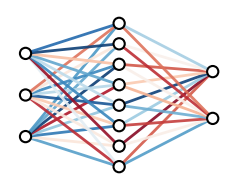

In [39]:
# Set random seed for reproducibility
rng = np.random.default_rng(42)

# Network structure
layers = [3, 8, 2]
layer_x = [0, 1, 2]
neuron_radius = 0.06

# Neuron positions (centralize input/output layers)
positions = []
for i, n_neurons in enumerate(layers):
    if n_neurons == 1:
        y = np.array([0.])
    else:
        # Centralize: spread neurons between -a and a, where a = (n_neurons-1)/n_neurons
        a = ((n_neurons - 1) / n_neurons)**2
        y = np.linspace(-0.5 * a, 0.5 * a, n_neurons) * 2
    x = np.full_like(y, layer_x[i], dtype=float)
    positions.append(list(zip(x, y)))

fig, ax = plt.subplots(figsize=(3, 2))
ax.axis('off')
ax.set_aspect('equal')  # Enforce aspect ratio 1

# Draw links with random colors
for l in range(len(layers) - 1):
    for i, (x0, y0) in enumerate(positions[l]):
        for j, (x1, y1) in enumerate(positions[l+1]):
            # Use RdBu colormap to pick a random color for each link
            cmap = plt.get_cmap('RdBu')
            ratio = rng.uniform(0, 1)
            color = cmap(ratio)
            ax.plot([x0, x1], [y0, y1], color=color, linewidth=2, alpha=0.9)

# Draw neurons
for l, layer in enumerate(positions):
    for (x, y) in layer:
        circle = plt.Circle((x, y), neuron_radius, color='w', ec='k', linewidth=1.5, zorder=3)
        ax.add_patch(circle)

plt.tight_layout()
plt.savefig('NN_init.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

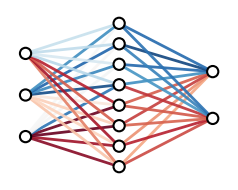

In [36]:
# Set random seed for reproducibility
rng = np.random.default_rng(242)

# Network structure
layers = [3, 8, 2]
layer_x = [0, 1, 2]
neuron_radius = 0.06

# Define base ratios per input for hidden-layer groups,
# group 0–3 in cooler tones, group 5–7 in warmer tones
n_input, n_hidden, n_output = layers
base_inp_hidden0 = rng.uniform(0.0, 0.4, size=n_input)
base_inp_hidden1 = rng.uniform(0.4, 1.0, size=n_input)
# Define base ratios per output for hidden→output groups,
# group 0–3 in cooler tones, group 5–7 in warmer tones
base_hid_out0 = rng.uniform(0.0, 0.4, size=n_output)
base_hid_out1 = rng.uniform(0.4, 1.0, size=n_output)

# Neuron positions (centralize input/output layers)
positions = []
for i, n_neurons in enumerate(layers):
    if n_neurons == 1:
        y = np.array([0.])
    else:
        # Centralize: spread neurons between -a and a, where a = (n_neurons-1)/n_neurons
        a = ((n_neurons - 1) / n_neurons)**2
        y = np.linspace(-0.5 * a, 0.5 * a, n_neurons) * 2
    x = np.full_like(y, layer_x[i], dtype=float)
    positions.append(list(zip(x, y)))

fig, ax = plt.subplots(figsize=(3, 2))
ax.axis('off')
ax.set_aspect('equal')  # Enforce aspect ratio 1

# Draw links with random colors
for l in range(len(layers) - 1):
    for i, (x0, y0) in enumerate(positions[l]):
        for j, (x1, y1) in enumerate(positions[l+1]):
            # Use RdBu colormap to pick a random color for each link
            cmap = plt.get_cmap('RdBu')
            # Group-based color assignments with per-node base + noise
            if l == 0:
                # input → hidden: same base for hidden neurons 0–3 or 5–7 per input i
                if j < 4:
                    base = base_inp_hidden0[i]
                elif j > 4:
                    base = base_inp_hidden1[i]
                else:
                    base = rng.uniform(0, 1)  # neuron 4 random
            else:
                # hidden → output: same base for hidden neurons 0–3 or 5–7 per output j
                if i < 4:
                    base = base_hid_out0[j]
                elif i > 4:
                    base = base_hid_out1[j]
                else:
                    base = rng.uniform(0, 1)  # neuron 4 random
            ratio = np.clip(base + rng.normal(0, 0.05), 0, 1)
            color = cmap(ratio)
            ax.plot([x0, x1], [y0, y1], color=color, linewidth=2, alpha=0.9)

# Draw neurons
for l, layer in enumerate(positions):
    for (x, y) in layer:
        circle = plt.Circle((x, y), neuron_radius, color='w', ec='k', linewidth=1.5, zorder=3)
        ax.add_patch(circle)

plt.tight_layout()
plt.savefig('NN_trained.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
# Load MNIST dataset
mnist = datasets.MNIST(root='./data', train=True, download=False, transform=transforms.ToTensor())

rng = np.random.default_rng(42)
images = [mnist[i][0] for i in rng.integers(0, 60000, 16)]

opacity = [[1,0,0,0], [0.6,0,0,0], [0,0,0.2,0],[0,0,0.5,1]]

# Create a 4x4 grid with thin spacing
fig, axes = plt.subplots(4, 4, figsize=(4, 4), gridspec_kw={'wspace':0.02, 'hspace':0.02})

for i, ax in enumerate(axes.flat):
    row, col = divmod(i, 4)
    alpha = opacity[row][col]
    # Invert black and white by subtracting from 1
    ax.imshow(1 - images[i].squeeze(), cmap='gray', alpha=alpha)
    ax.axis('off')

plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.margins(0,0)
plt.savefig("mnist_16_opacity.png", bbox_inches='tight', pad_inches=0)
plt.show()

NameError: name 'datasets' is not defined

FAISS tutorial

In [2]:
import numpy as np
d = 64                           # dimension
nb = 100000                      # database size
nq = 10000                       # nb of queries
np.random.seed(1234)             # make reproducible
xb = np.random.random((nb, d)).astype('float32')
xb[:, 0] += np.arange(nb) / 1000.
xq = np.random.random((nq, d)).astype('float32')
xq[:, 0] += np.arange(nq) / 1000.

In [3]:
import faiss                   # make faiss available
index = faiss.IndexFlatL2(d)   # build the index
print(index.is_trained)
index.add(xb)                  # add vectors to the index
print(index.ntotal)

True
100000


In [6]:
k = 4                          # we want to see 4 nearest neighbors
D, I = index.search(xb[:5], k) # sanity check
print(I)
print(D)
D, I = index.search(xq, k)     # actual search
print(I[:5])                   # neighbors of the 5 first queries
print(I[-5:])      

[[  0 393 363  78]
 [  1 555 277 364]
 [  2 304 101  13]
 [  3 173  18 182]
 [  4 288 370 531]]
[[0.        7.1751738 7.20763   7.2511625]
 [0.        6.323565  6.684581  6.799946 ]
 [0.        5.7964087 6.391736  7.2815123]
 [0.        7.2779055 7.527987  7.6628466]
 [0.        6.7638035 7.2951202 7.3688145]]
[[ 381  207  210  477]
 [ 526  911  142   72]
 [ 838  527 1290  425]
 [ 196  184  164  359]
 [ 526  377  120  425]]
[[ 9900 10500  9309  9831]
 [11055 10895 10812 11321]
 [11353 11103 10164  9787]
 [10571 10664 10632  9638]
 [ 9628  9554 10036  9582]]


## Try kmeans unsupervised learning

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs

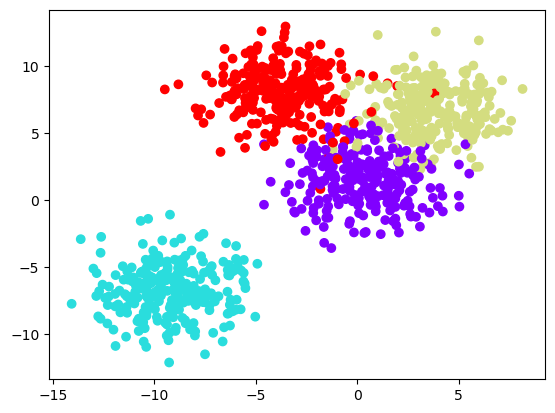

In [5]:
data = make_blobs(n_samples=1000, n_features=2, 
                           centers=4, cluster_std=1.8,random_state=101)  

plt.scatter(data[0][:,0],data[0][:,1],c=data[1],cmap='rainbow') 

In [7]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(data[0])

KMeans(n_clusters=4)

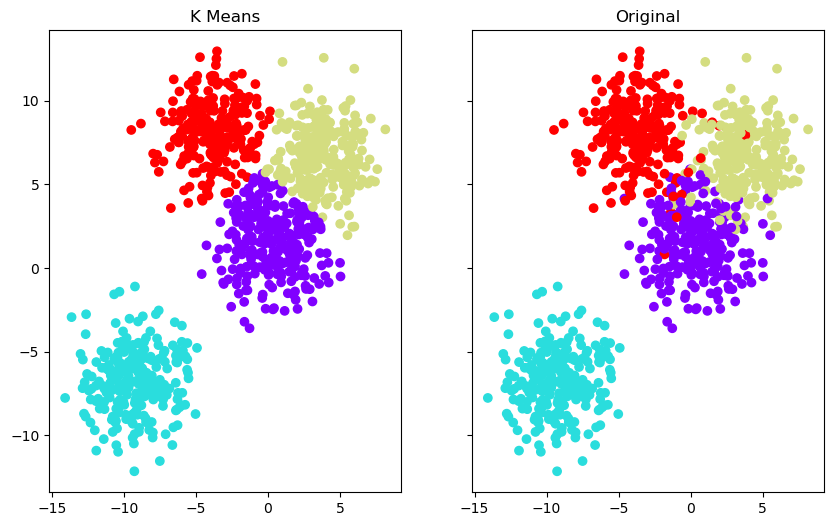

In [8]:
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True,figsize=(10,6))
ax1.set_title('K Means')
ax1.scatter(data[0][:,0],data[0][:,1],c=kmeans.labels_,cmap='rainbow')
ax2.set_title("Original")
ax2.scatter(data[0][:,0],data[0][:,1],c=data[1],cmap='rainbow')   